# Switching experiment dashboard

Notebook central pour suivre les expériences `switching_predictive`.

Objectif:

- lire automatiquement les runs `outputs/switching_predictive*`;
- comparer les métriques LOSO;
- comparer les baselines;
- visualiser les losses par user/fold;
- visualiser les distributions de labels et de prédictions;
- garder les commandes utiles dans le notebook.

Ce notebook ne lance pas l'entraînement par défaut. Il analyse les fichiers déjà générés.

## 1. Setup

In [17]:
from pathlib import Path
import json
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "fusion_model.py").is_file():
            return candidate
    raise RuntimeError("Project root not found")


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS = ROOT / "outputs"
DEFAULT_RUN = OUTPUTS / "switching_predictive"
plt.style.use("seaborn-v0_8-whitegrid")

print("ROOT:", ROOT)
print("OUTPUTS exists:", OUTPUTS.exists())

ROOT: C:\Users\medte\OneDrive\Desktop\Fusion_Model
OUTPUTS exists: True


In [18]:
def read_json(path: Path):
    if not path.is_file():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def read_csv(path: Path):
    if not path.is_file():
        return None
    return pd.read_csv(path)


def discover_switching_runs(outputs_dir: Path) -> list[Path]:
    runs = []
    for path in sorted(outputs_dir.glob("switching_predictive*")):
        if path.is_dir() and ((path / "loso_results.json").exists() or (path / "train_loso_results.json").exists()):
            runs.append(path)
    return runs


def load_run_summary(run_dir: Path) -> dict:
    loso = read_json(run_dir / "loso_results.json") or {}
    train = read_json(run_dir / "train_loso_results.json") or {}
    return {
        "run": run_dir.name,
        "state_mode": loso.get("state_mode", train.get("state_mode")),
        "task": train.get("task"),
        "class_weight_mode": train.get("class_weight_mode"),
        "state_loss": train.get("state_loss"),
        "num_folds": loso.get("num_folds", len(train.get("folds", [])) or None),
        "num_samples": loso.get("num_samples"),
        "state_accuracy": loso.get("state_accuracy"),
        "macro_f1": loso.get("macro_f1"),
        "mcc": loso.get("mcc"),
        "cohen_kappa": loso.get("cohen_kappa"),
        "factor_mae": loso.get("factor_mae"),
        "factor_rmse": loso.get("factor_rmse"),
        "has_baselines": (run_dir / "baselines.json").exists(),
        "has_user_reports": (run_dir / "user_label_distribution.csv").exists(),
    }


def display_or_print(df: pd.DataFrame):
    if df.empty:
        print("No data")
    else:
        display(df)

## 2. Discover available runs

In [19]:
runs = discover_switching_runs(OUTPUTS)
print("Runs found:", len(runs))
for run in runs:
    print("-", run.relative_to(ROOT))

Runs found: 7
- outputs\switching_predictive
- outputs\switching_predictive_3class
- outputs\switching_predictive_3class_dev_smoke
- outputs\switching_predictive_dev_smoke
- outputs\switching_predictive_regression_dev_smoke
- outputs\switching_predictive_regression_only
- outputs\switching_predictive_smoke


In [20]:
summary_df = pd.DataFrame([load_run_summary(run) for run in runs])
metric_cols = [
    "run", "state_mode", "task", "class_weight_mode", "state_loss",
    "num_folds", "num_samples", "state_accuracy", "macro_f1", "mcc",
    "cohen_kappa", "factor_mae", "factor_rmse", "has_baselines", "has_user_reports",
]
display_or_print(summary_df[[c for c in metric_cols if c in summary_df.columns]])

,run,state_mode,task,class_weight_mode,state_loss,num_folds,num_samples,state_accuracy,macro_f1,mcc,cohen_kappa,factor_mae,factor_rmse,has_baselines,has_user_reports
0,switching_predictive,5class,NaN,NaN,NaN,10,371.0,0.210243,0.069488,-0.299596,-0.182531,0.199803,0.268549,True,True
1,switching_predictive_3class,3class,joint,balanced,ce,10,371.0,0.223720,0.158314,-0.240608,-0.195676,0.233124,0.273336,True,True
2,switching_predictive_3class_dev_smoke,3class,joint,balanced,ce,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
3,switching_predictive_dev_smoke,5class,joint,balanced,ce,1,11.0,0.000000,0.000000,0.000000,0.000000,0.167102,0.200606,True,True
4,switching_predictive_regression_dev_smoke,5class,regression_only,none,ce,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
5,switching_predictive_regression_only,5class,regression_only,none,ce,10,371.0,0.199461,0.112939,-0.107615,-0.091890,0.250629,0.308872,True,True
6,switching_predictive_smoke,NaN,NaN,NaN,NaN,1,11.0,0.000000,0.000000,0.000000,0.000000,0.089825,0.105521,False,False


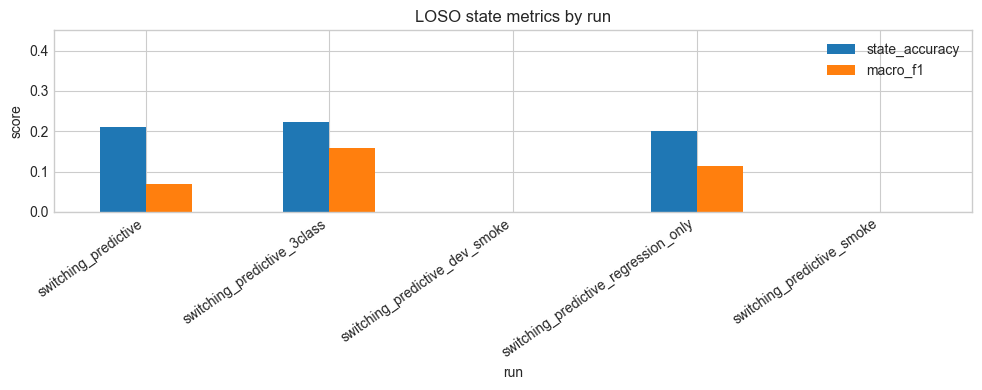

In [21]:
if not summary_df.empty:
    plot_df = summary_df.dropna(subset=["state_accuracy", "macro_f1"], how="all").copy()
    if not plot_df.empty:
        ax = plot_df.plot(x="run", y=["state_accuracy", "macro_f1"], kind="bar", figsize=(10, 4), title="LOSO state metrics by run")
        ax.set_ylabel("score")
        ax.set_ylim(0, max(0.45, float(plot_df[["state_accuracy", "macro_f1"]].max().max()) + 0.05))
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("No run metrics to plot.")

## 3. Select one run to inspect

In [22]:
# Change this if you want to inspect another run.
RUN_DIR = DEFAULT_RUN

print("RUN_DIR:", RUN_DIR.relative_to(ROOT))
loso = read_json(RUN_DIR / "loso_results.json") or {}
baselines = read_json(RUN_DIR / "baselines.json") or {}
fold_summary = read_csv(RUN_DIR / "loso_summary.csv")
user_labels = read_csv(RUN_DIR / "user_label_distribution.csv")
user_preds = read_csv(RUN_DIR / "user_prediction_distribution.csv")

print("loso_results:", bool(loso))
print("baselines:", bool(baselines))
print("fold_summary:", fold_summary is not None)
print("user_labels:", user_labels is not None)
print("user_preds:", user_preds is not None)

RUN_DIR: outputs\switching_predictive
loso_results: True
baselines: True
fold_summary: True
user_labels: True
user_preds: True


## 4. Overall metrics and confusion matrix

In [23]:
if loso:
    overall = {
        "state_mode": loso.get("state_mode"),
        "num_folds": loso.get("num_folds"),
        "num_samples": loso.get("num_samples"),
        "state_accuracy": loso.get("state_accuracy"),
        "macro_f1": loso.get("macro_f1"),
        "mcc": loso.get("mcc"),
        "cohen_kappa": loso.get("cohen_kappa"),
        "factor_mae": loso.get("factor_mae"),
        "factor_rmse": loso.get("factor_rmse"),
    }
    display(pd.DataFrame([overall]))
else:
    print("No loso_results.json for this run.")

,state_mode,num_folds,num_samples,state_accuracy,macro_f1,mcc,cohen_kappa,factor_mae,factor_rmse
0,5class,10,371,0.210243,0.069488,-0.299596,-0.182531,0.199803,0.268549


,pred_Flow,pred_Neutral,pred_Bored,pred_Distracted,pred_Overloaded
true_Flow,0,39,0,0,0
true_Neutral,0,78,0,47,0
true_Bored,0,65,0,0,0
true_Distracted,0,111,0,0,0
true_Overloaded,0,31,0,0,0


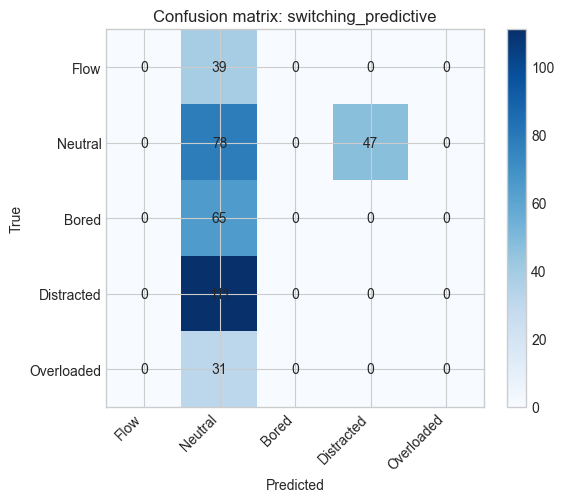

In [24]:
if loso and "confusion_matrix" in loso:
    state_names = loso.get("state_names") or ["Flow", "Neutral", "Bored", "Distracted", "Overloaded"]
    cm = np.asarray(loso["confusion_matrix"], dtype=int)
    cm_df = pd.DataFrame(cm, index=[f"true_{s}" for s in state_names], columns=[f"pred_{s}" for s in state_names])
    display(cm_df)

    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion matrix: {RUN_DIR.name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(len(state_names)))
    ax.set_yticks(range(len(state_names)))
    ax.set_xticklabels(state_names, rotation=45, ha="right")
    ax.set_yticklabels(state_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("No confusion matrix available.")

## 5. Baseline comparison

In [25]:
baseline_rows = []
for name, row in (baselines.get("baselines") or {}).items():
    baseline_rows.append({
        "baseline": name,
        "accuracy": row.get("state_accuracy"),
        "macro_f1": row.get("macro_f1"),
        "mcc": row.get("mcc"),
        "kappa": row.get("cohen_kappa"),
        "majority_class": row.get("majority_class"),
        "note": row.get("note"),
    })
baseline_df = pd.DataFrame(baseline_rows)
if not baseline_df.empty:
    baseline_df = baseline_df.sort_values("accuracy", ascending=False)
display_or_print(baseline_df)

,baseline,accuracy,macro_f1,mcc,kappa,majority_class,note
0,global_majority_reference,0.336927,0.100806,0.000000,0.000000,Neutral,Uses the full label distribution for interpret...
2,simple_mlp,0.296496,0.094624,-0.110122,-0.055954,NaN,NaN
1,majority_class,0.210243,0.073759,-0.245224,-0.177867,NaN,NaN
3,stratified_random,0.210243,0.151552,-0.037257,-0.036333,NaN,NaN


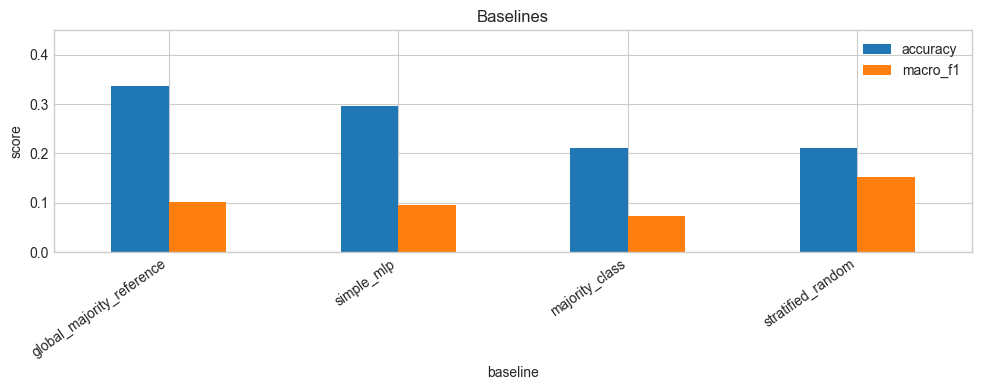

In [26]:
if not baseline_df.empty:
    ax = baseline_df.plot(x="baseline", y=["accuracy", "macro_f1"], kind="bar", figsize=(10, 4), title="Baselines")
    ax.set_ylabel("score")
    ax.set_ylim(0, max(0.45, float(baseline_df[["accuracy", "macro_f1"]].max().max()) + 0.05))
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No baselines.json. Run evaluation first.")

## 6. Per-user LOSO metrics

In [27]:
if fold_summary is not None:
    display(fold_summary)
else:
    print("No loso_summary.csv for this run.")

,test_user,num_samples,factor_mae,factor_rmse,state_accuracy,macro_f1,mcc,cohen_kappa,state_mode,task,class_weight_mode,state_loss,checkpoint
0,amrdroid,16,0.177339,0.221536,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_amrdroid\bes...
1,dem,161,0.134559,0.158108,0.21118,0.069744,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_dem\best.pt
2,ghoss,15,0.218621,0.274587,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_ghoss\best.pt
3,Graja,11,0.239358,0.278042,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_Graja\best.pt
4,hffz,41,0.300586,0.316238,0.04878,0.018605,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_hffz\best.pt
5,ignorant,16,0.059561,0.070276,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_ignorant\bes...
6,ladabos,16,0.218170,0.262594,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_ladabos\best.pt
7,layss,64,0.220657,0.373523,0.40625,0.115556,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_layss\best.pt
8,Makki,15,0.362409,0.390873,0.00000,0.000000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_Makki\best.pt
9,mohanned,16,0.461721,0.465105,1.00000,0.200000,0.0,0.0,5class,joint,none,ce,outputs\switching_predictive\fold_mohanned\bes...


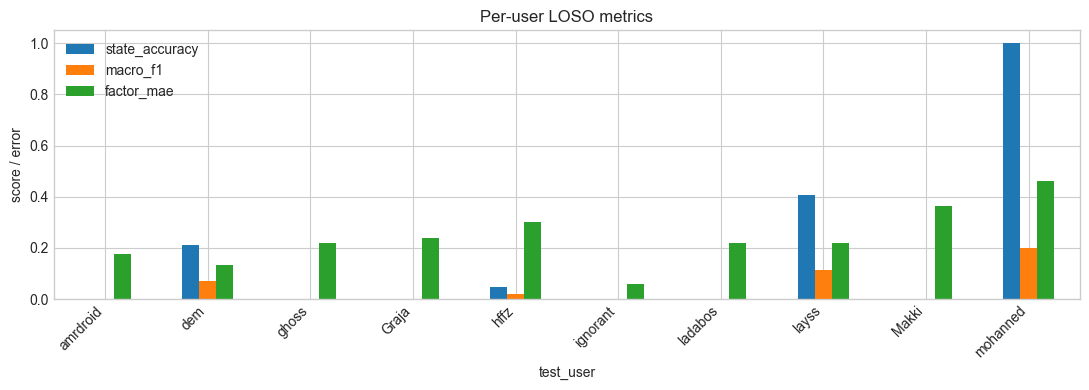

In [28]:
if fold_summary is not None and not fold_summary.empty:
    cols = [c for c in ["state_accuracy", "macro_f1", "factor_mae"] if c in fold_summary.columns]
    ax = fold_summary.plot(x="test_user", y=cols, kind="bar", figsize=(11, 4), title="Per-user LOSO metrics")
    ax.set_ylabel("score / error")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No per-user metrics to plot.")

## 7. User label shift and prediction collapse

In [29]:
if user_labels is not None:
    display(user_labels)
else:
    print("No user_label_distribution.csv.")

if user_preds is not None:
    display(user_preds)
else:
    print("No user_prediction_distribution.csv.")

,user_id,n_samples,n_sessions,Flow,Neutral,Bored,Distracted,Overloaded,majority_class,entropy
0,Graja,11,1,0,0,11,0,0,Bored,0.000000
1,Makki,15,1,0,0,15,0,0,Bored,0.000000
2,amrdroid,16,1,0,16,0,0,0,Neutral,0.000000
3,dem,161,10,16,34,16,95,0,Distracted,0.682576
4,ghoss,15,1,0,15,0,0,0,Neutral,0.000000
5,hffz,41,3,8,2,0,0,31,Overloaded,0.421008
6,ignorant,16,1,0,0,16,0,0,Bored,0.000000
7,ladabos,16,1,0,16,0,0,0,Neutral,0.000000
8,layss,64,5,15,26,7,16,0,Neutral,0.804381
9,mohanned,16,1,0,16,0,0,0,Neutral,0.000000


,user_id,n_samples,pred_Flow,pred_Neutral,pred_Bored,pred_Distracted,pred_Overloaded,state_accuracy,macro_f1,mcc,cohen_kappa
0,amrdroid,16,0,0,0,16,0,0.00000,0.000000,0.0,0.0
1,dem,161,0,161,0,0,0,0.21118,0.069744,0.0,0.0
2,ghoss,15,0,0,0,15,0,0.00000,0.000000,0.0,0.0
3,Graja,11,0,11,0,0,0,0.00000,0.000000,0.0,0.0
4,hffz,41,0,41,0,0,0,0.04878,0.018605,0.0,0.0
5,ignorant,16,0,16,0,0,0,0.00000,0.000000,0.0,0.0
6,ladabos,16,0,0,0,16,0,0.00000,0.000000,0.0,0.0
7,layss,64,0,64,0,0,0,0.40625,0.115556,0.0,0.0
8,Makki,15,0,15,0,0,0,0.00000,0.000000,0.0,0.0
9,mohanned,16,0,16,0,0,0,1.00000,0.200000,0.0,0.0


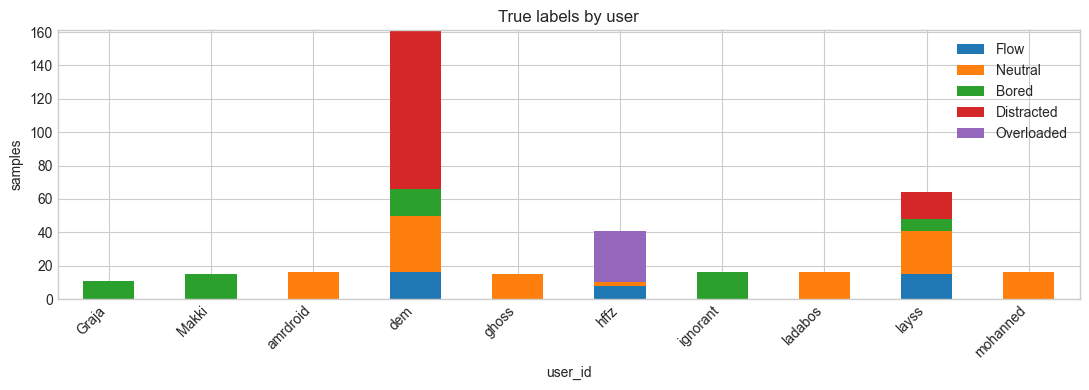

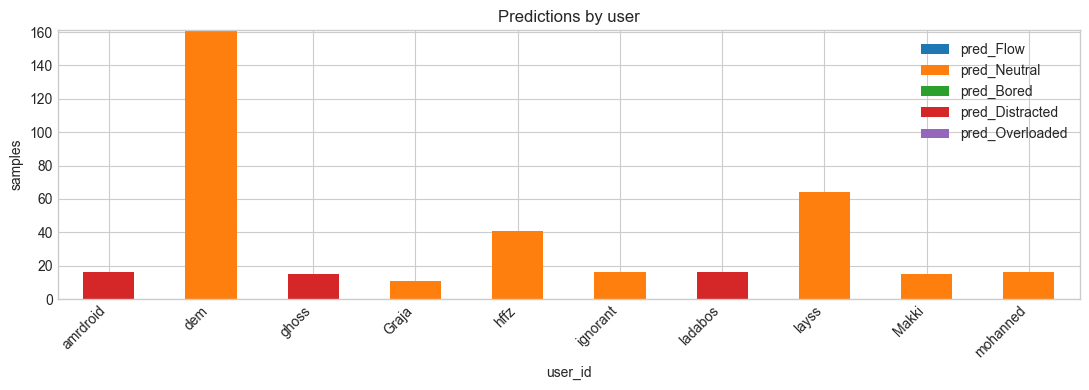

In [30]:
if user_labels is not None and not user_labels.empty:
    state_cols = [c for c in user_labels.columns if c not in ["user_id", "n_samples", "n_sessions", "majority_class", "entropy"]]
    ax = user_labels.set_index("user_id")[state_cols].plot(kind="bar", stacked=True, figsize=(11, 4), title="True labels by user")
    ax.set_ylabel("samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if user_preds is not None and not user_preds.empty:
    pred_cols = [c for c in user_preds.columns if c.startswith("pred_")]
    ax = user_preds.set_index("user_id")[pred_cols].plot(kind="bar", stacked=True, figsize=(11, 4), title="Predictions by user")
    ax.set_ylabel("samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 8. Training loss curves by fold/user

In [31]:
fold_histories = []
for path in sorted(RUN_DIR.glob("fold_*/history.csv")):
    df = pd.read_csv(path)
    df["user"] = path.parent.name.replace("fold_", "", 1)
    fold_histories.append(df)

history = pd.concat(fold_histories, ignore_index=True) if fold_histories else pd.DataFrame()
print("history rows:", len(history))
display_or_print(history.head())

history rows: 179


,epoch,train_loss,train_factor_loss,train_state_loss,train_state_accuracy,train_num_samples,val_loss,val_factor_loss,val_state_loss,val_state_accuracy,val_num_samples,user
0,1,0.995701,0.110831,1.585615,0.314706,340.0,0.939549,0.099437,1.499624,0.0,15.0,amrdroid
1,2,0.932717,0.046167,1.523749,0.326471,340.0,0.804191,0.031805,1.319115,0.0,15.0,amrdroid
2,3,0.925675,0.041591,1.515064,0.326471,340.0,0.777367,0.045039,1.265586,0.0,15.0,amrdroid
3,4,0.919487,0.035725,1.508662,0.326471,340.0,0.811406,0.056332,1.314790,0.0,15.0,amrdroid
4,5,0.916351,0.033498,1.504920,0.326471,340.0,0.783242,0.036550,1.281036,0.0,15.0,amrdroid


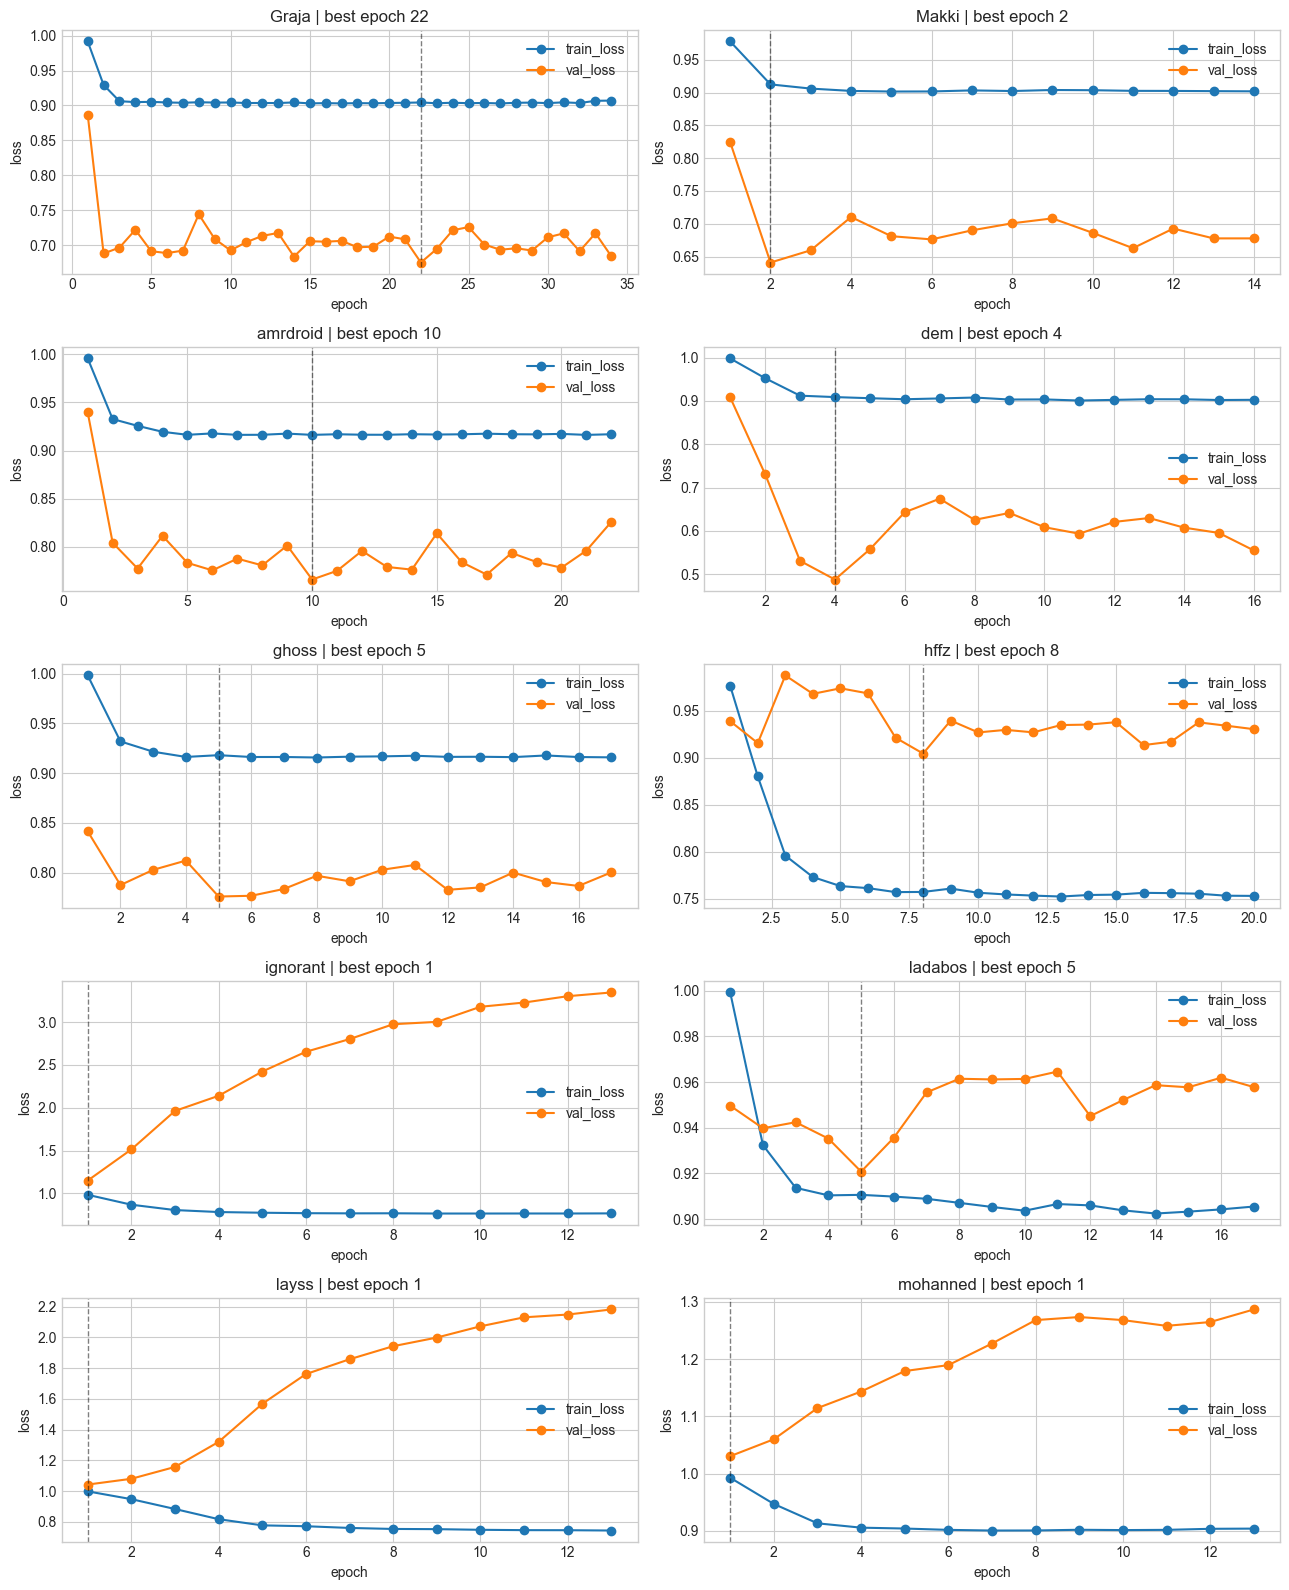

In [32]:
if not history.empty:
    users = sorted(history["user"].unique())
    ncols = 2
    nrows = math.ceil(len(users) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows), squeeze=False)
    for ax, user in zip(axes.ravel(), users):
        df = history[history["user"] == user].sort_values("epoch")
        ax.plot(df["epoch"], df["train_loss"], marker="o", label="train_loss")
        ax.plot(df["epoch"], df["val_loss"], marker="o", label="val_loss")
        if "val_loss" in df.columns:
            best = df.loc[df["val_loss"].idxmin()]
            ax.axvline(best["epoch"], color="black", linestyle="--", linewidth=1, alpha=0.5)
            ax.set_title(f"{user} | best epoch {int(best['epoch'])}")
        else:
            ax.set_title(user)
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.legend()
    for ax in axes.ravel()[len(users):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No fold history files found.")

## 9. Commands to generate/update results

Current 5-class evaluation:

```powershell
python scripts/switching/evaluate_switching_predictive.py --data-dir data_training --checkpoint-dir outputs/switching_predictive --device cpu
```

Balanced 5-class CE experiment:

```powershell
python scripts/switching/train_switching_predictive.py --data-dir data_training --state-mode 5class --class-weights balanced --state-loss ce --task joint --device cuda --output-dir outputs/switching_predictive_balanced_ce
python scripts/switching/evaluate_switching_predictive.py --data-dir data_training --checkpoint-dir outputs/switching_predictive_balanced_ce --device cpu
```

3-class experiment:

```powershell
python scripts/switching/train_switching_predictive.py --data-dir data_training --state-mode 3class --class-weights balanced --state-loss ce --task joint --device cuda --output-dir outputs/switching_predictive_3class
python scripts/switching/evaluate_switching_predictive.py --data-dir data_training --checkpoint-dir outputs/switching_predictive_3class --device cpu
```

Regression-only experiment:

```powershell
python scripts/switching/train_switching_predictive.py --data-dir data_training --task regression_only --device cuda --output-dir outputs/switching_predictive_regression_only
python scripts/switching/evaluate_switching_predictive.py --data-dir data_training --checkpoint-dir outputs/switching_predictive_regression_only --device cpu --skip-mlp-baseline
```

## 10. Reading guide

- Start with the run comparison table.
- Compare the model with `majority_class`, not only `global_majority_reference`.
- If predictions collapse to one or two classes, inspect the stacked prediction plot.
- If loss decreases but validation metrics remain weak, inspect user label shift.
- If factor MAE improves while state accuracy stays low, prefer regression or redesign the state mapping.